# CSI multi-task model v0 — hrc_ur10_cell (Stage 2, Scene 1)

STEP FOUR: train a small network to read the CSI and predict, from one
static snapshot, **presence / count / safety-zone** for the UR10 cell.

- **Backbone:** the verified Stage-1 tiny ResNet (~405k params).
- **Heads (new):** presence (binary), count (0/1/2), zone (none/green/yellow/red). A shared neck feeds all three.
- **Loss:** BCE(presence) + CE(count) + CE(zone, class-weighted so the rare red class is not ignored).
- **Input:** background-subtracted CSI (raw as an ablation).
- **Honest eval:** per-task accuracy / balanced-accuracy / macro-F1 / confusion matrix vs a majority-class floor, plus presence recall and red-zone recall (the safety-critical numbers).

> **IMPORTANT — run in a FRESH Colab runtime.** Do NOT run this in the same session as the data-generation notebook: that one pins `numpy==2.0.2` for Sionna, which breaks Colab's stock **torch** (`import torch` -> METH_CLASS/METH_STATIC error). This notebook uses **no Sionna** and needs stock torch. If you see that error: Runtime -> Disconnect and delete runtime, reconnect, re-upload the notebook + npz, Run all. Data-gen and training live in separate runtimes.

PyTorch only — trains in a couple of minutes on Colab GPU or CPU. Upload this notebook + `hrc_ur10_cell_data_v0_robot.npz` into /content.

In [8]:
# ================================================================
# SETUP + FILES  (torch + sklearn are preinstalled on Colab)
# ================================================================
import os, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                             confusion_matrix, recall_score)

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False
IN_COLAB = _in_colab()

DATA_NAME = 'hrc_ur10_cell_data_v0_robot.npz'
if IN_COLAB:
    hits = list(Path('/content').rglob(DATA_NAME))
    if not hits:
        raise FileNotFoundError(f'{DATA_NAME} not found under /content -- upload it.')
    NPZ_PATH = str(hits[0]); BASE_DIR = '/content'
else:
    BASE_DIR = os.getcwd(); NPZ_PATH = os.path.join(BASE_DIR, DATA_NAME)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device', DEVICE)
print('data :', NPZ_PATH)

torch 2.11.0+cpu | device cpu
data : /content/hrc_ur10_cell_data_v0_robot.npz


In [9]:
# ================================================================
# CONFIG
# ================================================================
INPUT = 'bgsub'          # 'bgsub' (primary) or 'raw' (ablation)
BATCH = 128
EPOCHS = 120
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.2          # neck dropout (overfitting defense)
SUBCARRIER_DROPOUT = 0.1 # train-time aug: zero a fraction of subcarriers

# backbone widths (Stage-1 defaults, ~405k params)
STEM_CH = 32
STAGE_CH = [32, 64, 96, 96]
STAGE_DS = [False, True, True, True]   # downsample subcarrier axis 64->8

N_COUNT, N_ZONE = 3, 4   # count classes {0,1,2}; zone {none,green,yellow,red}
ZONE_NAMES = ['none', 'green', 'yellow', 'red']
torch.manual_seed(0); np.random.seed(0)

In [10]:
# ================================================================
# DATA: load, reshape to [N,8,4,64], standardize on TRAIN only
# ================================================================
z = np.load(NPZ_PATH, allow_pickle=True)
csi = z['csi_bgsub'] if INPUT == 'bgsub' else z['csi_raw']   # [N,M_AP,K_TX,N_sub] complex
presence = z['presence'].astype(np.int64)
count = z['count'].astype(np.int64)
zone = z['zone'].astype(np.int64)
split = z['split'].astype(str)
N, M_AP, K_TX, N_SUB = csi.shape

def to_input(c):
    # complex [N,M_AP,K_TX,N_sub] -> real [N, 2*K_TX, M_AP, N_sub]  (= [N,8,4,64])
    s = np.stack([c.real, c.imag], axis=1)        # [N,2,M_AP,K_TX,N_sub]
    s = np.transpose(s, (0, 1, 3, 2, 4))          # [N,2,K_TX,M_AP,N_sub]
    return s.reshape(c.shape[0], 2 * K_TX, M_AP, N_SUB).astype(np.float32)

X = to_input(csi)
tr, va, te = split == 'train', split == 'val', split == 'test'

# per-channel standardization from TRAIN
x_mean = X[tr].mean(axis=(0, 2, 3), keepdims=True)
x_std = X[tr].std(axis=(0, 2, 3), keepdims=True) + 1e-6
Xn = (X - x_mean) / x_std

print('X', Xn.shape, '| input =', INPUT)
print('train/val/test:', int(tr.sum()), int(va.sum()), int(te.sum()))
for nm, arr in [('presence', presence), ('count', count), ('zone', zone)]:
    print(f'  {nm:9s} train balance:', np.bincount(arr[tr]).tolist())

X (8000, 8, 4, 64) | input = bgsub
train/val/test: 5602 1199 1199
  presence  train balance: [1860, 3742]
  count     train balance: [1860, 1883, 1859]
  zone      train balance: [1860, 2054, 986, 702]


In [11]:
# ================================================================
# LOADERS
# ================================================================
def loader(mask, shuffle):
    ds = TensorDataset(torch.tensor(Xn[mask]),
                       torch.tensor(presence[mask]),
                       torch.tensor(count[mask]),
                       torch.tensor(zone[mask]))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, drop_last=False)

dl_tr, dl_va, dl_te = loader(tr, True), loader(va, False), loader(te, False)

# zone class weights (inverse frequency on train) -> up-weight rare red
zc = np.bincount(zone[tr], minlength=N_ZONE).astype(np.float32)
zw = (zc.sum() / (N_ZONE * np.maximum(zc, 1)))
zone_w = torch.tensor(zw / zw.mean(), dtype=torch.float32, device=DEVICE)
print('zone class weights:', zone_w.cpu().numpy().round(2))

zone class weights: [0.62 0.56 1.17 1.65]


In [12]:
# ================================================================
# MODEL: Stage-1 tiny ResNet backbone + shared neck + 3 heads
# ================================================================
class BasicBlock(nn.Module):
    """ResNet basic block. Stride (1, s) downsamples ONLY the subcarrier (width) axis."""
    def __init__(self, cin, cout, stride_w=1):
        super().__init__()
        s = (1, stride_w)
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=s, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.proj = None
        if cin != cout or stride_w != 1:
            self.proj = nn.Sequential(nn.Conv2d(cin, cout, 1, stride=s, bias=False),
                                      nn.BatchNorm2d(cout))
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        idt = x if self.proj is None else self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class CSINetMulti(nn.Module):
    def __init__(self, in_ch=8, stem=STEM_CH, stage_ch=STAGE_CH, stage_ds=STAGE_DS,
                 p=DROPOUT_P):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_ch, stem, 3, padding=1, bias=False),
                                  nn.BatchNorm2d(stem), nn.ReLU(inplace=True))
        blocks, c = [], stem
        for cout, ds in zip(stage_ch, stage_ds):
            blocks.append(BasicBlock(c, cout, stride_w=2 if ds else 1)); c = cout
        self.stages = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.neck = nn.Sequential(nn.Linear(c, 64), nn.ReLU(inplace=True), nn.Dropout(p))
        self.head_presence = nn.Linear(64, 1)
        self.head_count = nn.Linear(64, N_COUNT)
        self.head_zone = nn.Linear(64, N_ZONE)

    def forward(self, x):
        f = self.pool(self.stages(self.stem(x))).flatten(1)
        f = self.neck(f)
        return self.head_presence(f).squeeze(1), self.head_count(f), self.head_zone(f)


model = CSINetMulti().to(DEVICE)
print(f'trainable params: {sum(p.numel() for p in model.parameters()):,}')

trainable params: 406,024


In [13]:
# ================================================================
# TRAIN — multi-task loss; select best by mean balanced-accuracy
# ================================================================
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
bce = nn.BCEWithLogitsLoss(); ce = nn.CrossEntropyLoss()
ce_zone = nn.CrossEntropyLoss(weight=zone_w)

def sc_dropout(xb):
    if SUBCARRIER_DROPOUT <= 0: return xb
    keep = (torch.rand(xb.shape[-1], device=xb.device) > SUBCARRIER_DROPOUT).float()
    return xb * keep

@torch.no_grad()
def evaluate(dl):
    model.eval(); P = {k: [] for k in ['p', 'c', 'z']}; T = {k: [] for k in ['p', 'c', 'z']}
    for xb, yp, yc, yz in dl:
        pl, cl, zl = model(xb.to(DEVICE))
        P['p'].append((torch.sigmoid(pl) > 0.5).long().cpu()); T['p'].append(yp)
        P['c'].append(cl.argmax(1).cpu()); T['c'].append(yc)
        P['z'].append(zl.argmax(1).cpu()); T['z'].append(yz)
    P = {k: torch.cat(v).numpy() for k, v in P.items()}
    T = {k: torch.cat(v).numpy() for k, v in T.items()}
    bacc = {k: balanced_accuracy_score(T[k], P[k]) for k in P}
    return P, T, bacc

best, best_state, hist = -1, None, []
t0 = time.time()
for ep in range(1, EPOCHS + 1):
    model.train(); run = 0.0
    for xb, yp, yc, yz in dl_tr:
        xb = sc_dropout(xb.to(DEVICE))
        yp, yc, yz = yp.float().to(DEVICE), yc.to(DEVICE), yz.to(DEVICE)
        pl, cl, zl = model(xb)
        loss = bce(pl, yp) + ce(cl, yc) + ce_zone(zl, yz)
        opt.zero_grad(); loss.backward(); opt.step()
        run += loss.item() * xb.size(0)
    sched.step()
    _, _, bacc = evaluate(dl_va)
    meanb = np.mean(list(bacc.values()))
    hist.append((run / int(tr.sum()), bacc['p'], bacc['c'], bacc['z']))
    if meanb > best:
        best = meanb
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if ep % 10 == 0 or ep == 1:
        print(f"ep {ep:3d} loss {hist[-1][0]:.3f} | bal-acc P {bacc['p']:.3f} "
              f"C {bacc['c']:.3f} Z {bacc['z']:.3f} (mean {meanb:.3f}, best {best:.3f})")
model.load_state_dict(best_state)
print(f'\ndone in {(time.time()-t0)/60:.1f} min | best mean balanced-acc {best:.3f}')

ep   1 loss 2.231 | bal-acc P 0.990 C 0.768 Z 0.567 (mean 0.775, best 0.775)
ep  10 loss 1.113 | bal-acc P 0.999 C 0.749 Z 0.609 (mean 0.786, best 0.803)
ep  20 loss 0.806 | bal-acc P 0.999 C 0.793 Z 0.615 (mean 0.803, best 0.814)
ep  30 loss 0.530 | bal-acc P 0.998 C 0.771 Z 0.621 (mean 0.797, best 0.817)
ep  40 loss 0.225 | bal-acc P 0.999 C 0.776 Z 0.621 (mean 0.799, best 0.817)
ep  50 loss 0.125 | bal-acc P 0.999 C 0.744 Z 0.648 (mean 0.797, best 0.817)
ep  60 loss 0.071 | bal-acc P 0.999 C 0.780 Z 0.636 (mean 0.805, best 0.817)
ep  70 loss 0.051 | bal-acc P 0.999 C 0.768 Z 0.644 (mean 0.804, best 0.817)
ep  80 loss 0.028 | bal-acc P 0.999 C 0.775 Z 0.632 (mean 0.802, best 0.817)
ep  90 loss 0.027 | bal-acc P 0.999 C 0.769 Z 0.620 (mean 0.796, best 0.817)
ep 100 loss 0.018 | bal-acc P 0.999 C 0.767 Z 0.643 (mean 0.803, best 0.817)
ep 110 loss 0.017 | bal-acc P 0.999 C 0.765 Z 0.631 (mean 0.798, best 0.817)
ep 120 loss 0.013 | bal-acc P 0.999 C 0.769 Z 0.628 (mean 0.799, best 0.817)

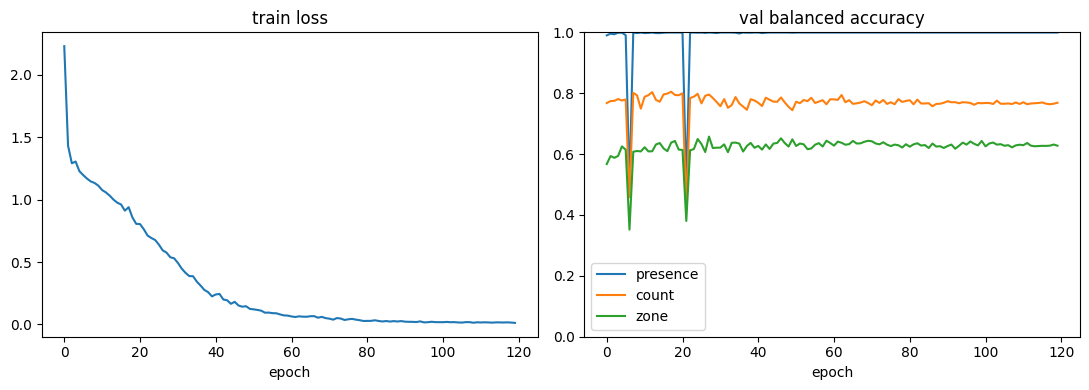

In [14]:
  # --- learning curves (per-task validation balanced accuracy) ---
h = np.array(hist)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h[:, 0]); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(h[:, 1], label='presence'); ax[1].plot(h[:, 2], label='count'); ax[1].plot(h[:, 3], label='zone')
ax[1].set_title('val balanced accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].set_ylim(0, 1)
fig.tight_layout(); plt.show()

task      acc    bal-acc  macroF1  | majority-floor
presence  0.998  0.999   0.998    | 0.668
count     0.774  0.775   0.772    | 0.336
zone      0.688  0.629   0.611    | 0.372

SAFETY: presence recall 0.998 | red-zone recall 0.597


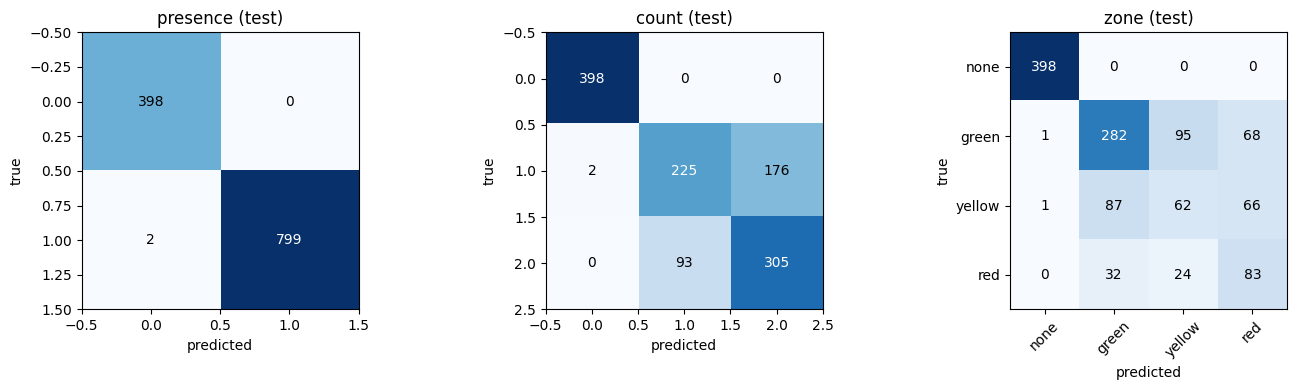

In [15]:
# ================================================================
# TEST EVALUATION — metrics vs majority floors + safety recalls
# ================================================================
P, T, _ = evaluate(dl_te)

def majority_floor(train_labels, test_labels):
    maj = np.bincount(train_labels).argmax()
    return (test_labels == maj).mean()

tasks = [('presence', 'p', presence), ('count', 'c', count), ('zone', 'z', zone)]
print('task      acc    bal-acc  macroF1  | majority-floor')
for name, k, arr in tasks:
    acc = (P[k] == T[k]).mean()
    bacc = balanced_accuracy_score(T[k], P[k])
    f1 = f1_score(T[k], P[k], average='macro')
    floor = majority_floor(arr[tr], arr[te])
    print(f'{name:9s} {acc:.3f}  {bacc:.3f}   {f1:.3f}    | {floor:.3f}')

# safety-critical recalls
pres_recall = recall_score(T['p'], P['p'], pos_label=1)
red_recall = recall_score(T['z'] == 3, P['z'] == 3)
print(f'\nSAFETY: presence recall {pres_recall:.3f} | red-zone recall {red_recall:.3f}')

# confusion matrices
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (name, k, _) in zip(ax, tasks):
    cm = confusion_matrix(T[k], P[k])
    im = a.imshow(cm, cmap='Blues'); a.set_title(f'{name} (test)')
    a.set_xlabel('predicted'); a.set_ylabel('true')
    for (r, cc), v in np.ndenumerate(cm):
        a.text(cc, r, int(v), ha='center', va='center',
               color='white' if v > cm.max()/2 else 'black')
    if name == 'zone':
        a.set_xticks(range(4)); a.set_xticklabels(ZONE_NAMES, rotation=45)
        a.set_yticks(range(4)); a.set_yticklabels(ZONE_NAMES)
fig.tight_layout(); plt.show()

In [16]:
# --- save trained model + config ---
ckpt = os.path.join(BASE_DIR, f'csi_multitask_v0_{INPUT}.pt')
torch.save({'state_dict': model.state_dict(),
            'x_mean': x_mean, 'x_std': x_std,
            'stage_ch': STAGE_CH, 'stage_ds': STAGE_DS, 'stem': STEM_CH,
            'input': INPUT, 'dropout_p': DROPOUT_P,
            'best_mean_balacc': best}, ckpt)
print('saved', ckpt)

saved /content/csi_multitask_v0_bgsub.pt


## What to look for

- **Presence and count** should beat their majority floors clearly and
  sit high — the background-subtracted signal separates 0/1/2 people
  cleanly. If they don’t, something is wrong with the input pipeline.
- **Zone** is the real test (it needs *where*, not just *whether*).
  Watch the zone confusion matrix: confusions should be between
  *adjacent* rings (green↔yellow, yellow↔red), not green↔red.
- **Safety recalls**: presence recall and especially **red-zone recall**
  are the numbers that matter for the use case — a missed red is the
  costly error.
- **Overfitting**: if val balanced-accuracy peaks then drops, raise
  `DROPOUT_P` / `SUBCARRIER_DROPOUT` / `WEIGHT_DECAY`.

Next: the **O3 ablation** (set `INPUT='raw'` and compare), then the
**robot-vs-norobot** coverage result (regenerate data with
`VARIANT='norobot'` and retrain).